In [1]:
import os
import numpy as np
import random
import torch
from torch_geometric.data import Data, DataLoader

# Set random seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# Set the seed
set_seed(42)


# Function to load graph data
def load_graph_data(file_path):
    data = np.load(file_path)
    adjacency_matrix = data['adjacency_matrix']
    mean_matrix = data['mean_matrix']
    data_label = data['label']
    return adjacency_matrix, mean_matrix, data_label



# Prepare train and test datasets
def prepare_dataset(data_dir):
    dataset = []
    for file_name in os.listdir(data_dir):
        if file_name.endswith('.npz'):
            # label = int(file_name.split('_')[3])  # Extract label from filename
            file_path = os.path.join(data_dir, file_name)
            
            # Load adjacency matrix and mean matrix
            adjacency_matrix, mean_matrix, label = load_graph_data(file_path)
            
            # Convert adjacency matrix to edge index format
            edge_index = torch.tensor(np.array(np.where(adjacency_matrix == 0)), dtype=torch.long)
            
            # Convert mean matrix to node features
            x = torch.tensor(mean_matrix, dtype=torch.float)
            
            # Create PyTorch Geometric Data object
            graph = Data(x=x, edge_index=edge_index, y=torch.tensor([int(label)], dtype=torch.long))
            
            dataset.append(graph)
    return dataset


from torch.nn import Linear
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
import torch_geometric

class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.fc = Linear(hidden_channels, out_channels)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.conv3(x, edge_index)
        x = F.relu(x)
        x = torch_geometric.nn.global_mean_pool(x, batch)  # Global pooling for each graph in the batch
        x = self.fc(x)
        return F.log_softmax(x, dim=1)  # Output shape: [batch_size, num_classes]
    
    
# Training loop
def train():
    model.train()
    total_loss = 0
    correct = 0
    for data in train_loader:
        optimizer.zero_grad()
        
        # Move data to the same device as the model
        data = data.to(device)
        
        # Forward pass
        out = model(data)  # Output shape: [batch_size, num_classes]
        
        # Compute loss
        loss = criterion(out, data.y)  # data.y shape: [batch_size]
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        pred = out.argmax(dim=1)  # Get predicted class for each graph
        correct += (pred == data.y).sum().item()  # Compare with true labels
        
    return total_loss / len(train_loader), correct / len(train_loader.dataset)

def test(loader):
    model.eval()
    correct = 0
    for data in loader:
        data = data.to(device)
        out = model(data)  # Output shape: [batch_size, num_classes]
        pred = out.argmax(dim=1)  # Get predicted class for each graph
        correct += (pred == data.y).sum().item()  # Compare with true labels
    return correct / len(loader.dataset)


import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score
import os

def final_evaluation_and_save(model, data_loader, num_classes, device, experiment_name,
                              metrics_csv_path="generalization_metrics.csv",
                              log_txt_path="generalization_predictions.log"):

    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for data in data_loader:
            data = data.to(device)
            out = model(data)
            preds = out.argmax(dim=1).cpu().numpy()
            labels = data.y.cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels)

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # ---- Save logs ----
    with open(log_txt_path, "a") as f:
        f.write(f"\n===== Experiment: {experiment_name} =====\n")
        for true, pred in zip(all_labels, all_preds):
            f.write(f"Label: {true}, Pred: {pred}\n")

    # ---- Metrics ----
    precision, recall, f1, support = precision_recall_fscore_support(
        all_labels, all_preds, average='weighted', zero_division=0
    )

    try:
        y_true_oh = np.eye(num_classes)[all_labels]
        y_pred_oh = np.eye(num_classes)[all_preds]
        auc = roc_auc_score(y_true_oh, y_pred_oh, multi_class='ovo', average='weighted')
    except Exception as e:
        auc = None

    # ---- Save metrics ----
    metrics_row = {
        "Experiment": experiment_name,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "AUC": auc
    }

    df_row = pd.DataFrame([metrics_row])
    if os.path.exists(metrics_csv_path):
        df_row.to_csv(metrics_csv_path, mode='a', header=False, index=False)
    else:
        df_row.to_csv(metrics_csv_path, mode='w', header=True, index=False)

    print(f"Saved logs to {log_txt_path}")
    print(f"Saved metrics to {metrics_csv_path}")

In [2]:
import os
from torch.optim import Adam

# Base directory containing subject folders
base_dir = r"D:\IDL_PROJECT_DATA\Final\clustering\Results\GENERALIZABLE-CASE"
subject_dirs = [d for d in os.listdir(base_dir) if d.startswith("subject_")]


for subject in subject_dirs:
    print(f"\n==== Running experiment for {subject} ====")

    train_dir = os.path.join(base_dir, subject, "train")
    test_dir = os.path.join(base_dir, subject, "test")

    # Prepare dataset
    train_data = prepare_dataset(train_dir)
    test_data = prepare_dataset(test_dir)

    # Skip if there's no data
    if len(train_data) == 0 or len(test_data) == 0:
        print(f"Skipping {subject}: No data found.")
        continue

    # Prepare DataLoader
    train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=32, shuffle=False)
    
    # Move model to appropriate device
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # Define model
    num_node_features = train_data[0].x.shape[1]
    num_classes = len(set([data.y.item() for data in train_data + test_data]))
    model = GCN(num_node_features, hidden_channels=64, out_channels=num_classes).to(device)
    

    optimizer = Adam(model.parameters(), lr=0.0001)
    criterion = torch.nn.CrossEntropyLoss()
    
    log_path = f"{subject}_metrics.log"

    # Train model
    for epoch in range(50):
        train_loss, train_acc = train()
        test_acc = test(test_loader)
        # print(f'{subject} | Epoch {epoch+1}, Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}')
        log_entry = f'{subject} | Epoch {epoch+1}, Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}'
        print(log_entry)
        
        with open(log_path, "a") as f:
            f.write(log_entry + "\n")

    # Final evaluation and logging
    final_evaluation_and_save(
        model=model,
        data_loader=test_loader,
        num_classes=num_classes,
        device=device,
        experiment_name=subject,
        metrics_csv_path="generalization_metrics.csv",
        log_txt_path="generalization_predictions.log"
    )



==== Running experiment for subject_3-5 ====


c:\Users\mayur\anaconda3\envs\cmu\lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


subject_3-5 | Epoch 1, Loss: 0.5237, Train Acc: 0.8054, Test Acc: 0.8256
subject_3-5 | Epoch 2, Loss: 0.4629, Train Acc: 0.8327, Test Acc: 0.8287
subject_3-5 | Epoch 3, Loss: 0.4508, Train Acc: 0.8350, Test Acc: 0.8220
subject_3-5 | Epoch 4, Loss: 0.4414, Train Acc: 0.8360, Test Acc: 0.8231
subject_3-5 | Epoch 5, Loss: 0.4332, Train Acc: 0.8364, Test Acc: 0.8218
subject_3-5 | Epoch 6, Loss: 0.4256, Train Acc: 0.8381, Test Acc: 0.8225
subject_3-5 | Epoch 7, Loss: 0.4194, Train Acc: 0.8388, Test Acc: 0.8161
subject_3-5 | Epoch 8, Loss: 0.4122, Train Acc: 0.8400, Test Acc: 0.8183
subject_3-5 | Epoch 9, Loss: 0.4056, Train Acc: 0.8412, Test Acc: 0.8070
subject_3-5 | Epoch 10, Loss: 0.4002, Train Acc: 0.8426, Test Acc: 0.8176
subject_3-5 | Epoch 11, Loss: 0.3943, Train Acc: 0.8438, Test Acc: 0.8149
subject_3-5 | Epoch 12, Loss: 0.3887, Train Acc: 0.8450, Test Acc: 0.8123
subject_3-5 | Epoch 13, Loss: 0.3834, Train Acc: 0.8463, Test Acc: 0.8137
subject_3-5 | Epoch 14, Loss: 0.3776, Train Acc

c:\Users\mayur\anaconda3\envs\cmu\lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


subject_3-6 | Epoch 1, Loss: 0.5061, Train Acc: 0.8173, Test Acc: 0.8313
subject_3-6 | Epoch 2, Loss: 0.4662, Train Acc: 0.8331, Test Acc: 0.8335
subject_3-6 | Epoch 3, Loss: 0.4534, Train Acc: 0.8340, Test Acc: 0.8320
subject_3-6 | Epoch 4, Loss: 0.4448, Train Acc: 0.8348, Test Acc: 0.8329
subject_3-6 | Epoch 5, Loss: 0.4366, Train Acc: 0.8352, Test Acc: 0.8338
subject_3-6 | Epoch 6, Loss: 0.4299, Train Acc: 0.8356, Test Acc: 0.8299
subject_3-6 | Epoch 7, Loss: 0.4229, Train Acc: 0.8365, Test Acc: 0.8324
subject_3-6 | Epoch 8, Loss: 0.4168, Train Acc: 0.8383, Test Acc: 0.8310
subject_3-6 | Epoch 9, Loss: 0.4104, Train Acc: 0.8391, Test Acc: 0.8306
subject_3-6 | Epoch 10, Loss: 0.4042, Train Acc: 0.8409, Test Acc: 0.8292
subject_3-6 | Epoch 11, Loss: 0.3986, Train Acc: 0.8417, Test Acc: 0.8295
subject_3-6 | Epoch 12, Loss: 0.3930, Train Acc: 0.8442, Test Acc: 0.8281
subject_3-6 | Epoch 13, Loss: 0.3882, Train Acc: 0.8449, Test Acc: 0.8249
subject_3-6 | Epoch 14, Loss: 0.3828, Train Acc

...

subject_5-6 | Epoch 1, Loss: 0.5048, Train Acc: 0.8227, Test Acc: 0.8317
subject_5-6 | Epoch 2, Loss: 0.4654, Train Acc: 0.8325, Test Acc: 0.8337
subject_5-6 | Epoch 3, Loss: 0.4505, Train Acc: 0.8340, Test Acc: 0.8338
subject_5-6 | Epoch 4, Loss: 0.4393, Train Acc: 0.8349, Test Acc: 0.8339
subject_5-6 | Epoch 5, Loss: 0.4306, Train Acc: 0.8360, Test Acc: 0.8327
subject_5-6 | Epoch 6, Loss: 0.4224, Train Acc: 0.8373, Test Acc: 0.8332
subject_5-6 | Epoch 7, Loss: 0.4155, Train Acc: 0.8380, Test Acc: 0.8348
subject_5-6 | Epoch 8, Loss: 0.4084, Train Acc: 0.8389, Test Acc: 0.8321
subject_5-6 | Epoch 9, Loss: 0.4029, Train Acc: 0.8400, Test Acc: 0.8326
subject_5-6 | Epoch 10, Loss: 0.3964, Train Acc: 0.8418, Test Acc: 0.8330
subject_5-6 | Epoch 11, Loss: 0.3904, Train Acc: 0.8442, Test Acc: 0.8290
subject_5-6 | Epoch 12, Loss: 0.3853, Train Acc: 0.8453, Test Acc: 0.8308
subject_5-6 | Epoch 13, Loss: 0.3799, Train Acc: 0.8461, Test Acc: 0.8299
subject_5-6 | Epoch 14, Loss: 0.3745, Train Acc

c:\Users\mayur\anaconda3\envs\cmu\lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


subject_5-7 | Epoch 1, Loss: 0.4799, Train Acc: 0.8297, Test Acc: 0.8320
subject_5-7 | Epoch 2, Loss: 0.4524, Train Acc: 0.8327, Test Acc: 0.8319
subject_5-7 | Epoch 3, Loss: 0.4416, Train Acc: 0.8341, Test Acc: 0.8325
subject_5-7 | Epoch 4, Loss: 0.4327, Train Acc: 0.8349, Test Acc: 0.8310
subject_5-7 | Epoch 5, Loss: 0.4257, Train Acc: 0.8356, Test Acc: 0.8307
subject_5-7 | Epoch 6, Loss: 0.4191, Train Acc: 0.8373, Test Acc: 0.8315
subject_5-7 | Epoch 7, Loss: 0.4129, Train Acc: 0.8380, Test Acc: 0.8323
subject_5-7 | Epoch 8, Loss: 0.4074, Train Acc: 0.8399, Test Acc: 0.8296
subject_5-7 | Epoch 9, Loss: 0.4022, Train Acc: 0.8399, Test Acc: 0.8296
subject_5-7 | Epoch 10, Loss: 0.3968, Train Acc: 0.8413, Test Acc: 0.8257
subject_5-7 | Epoch 11, Loss: 0.3915, Train Acc: 0.8433, Test Acc: 0.8293
subject_5-7 | Epoch 12, Loss: 0.3866, Train Acc: 0.8438, Test Acc: 0.8249
subject_5-7 | Epoch 13, Loss: 0.3813, Train Acc: 0.8460, Test Acc: 0.8223
subject_5-7 | Epoch 14, Loss: 0.3768, Train Acc

c:\Users\mayur\anaconda3\envs\cmu\lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


subject_6-7 | Epoch 1, Loss: 0.5351, Train Acc: 0.7925, Test Acc: 0.8310
subject_6-7 | Epoch 2, Loss: 0.4658, Train Acc: 0.8326, Test Acc: 0.8330
subject_6-7 | Epoch 3, Loss: 0.4539, Train Acc: 0.8337, Test Acc: 0.8331
subject_6-7 | Epoch 4, Loss: 0.4454, Train Acc: 0.8339, Test Acc: 0.8333
subject_6-7 | Epoch 5, Loss: 0.4372, Train Acc: 0.8346, Test Acc: 0.8327
subject_6-7 | Epoch 6, Loss: 0.4302, Train Acc: 0.8352, Test Acc: 0.8324
subject_6-7 | Epoch 7, Loss: 0.4230, Train Acc: 0.8371, Test Acc: 0.8324
subject_6-7 | Epoch 8, Loss: 0.4168, Train Acc: 0.8380, Test Acc: 0.8327
subject_6-7 | Epoch 9, Loss: 0.4103, Train Acc: 0.8397, Test Acc: 0.8320
subject_6-7 | Epoch 10, Loss: 0.4037, Train Acc: 0.8415, Test Acc: 0.8289
subject_6-7 | Epoch 11, Loss: 0.3980, Train Acc: 0.8432, Test Acc: 0.8304
subject_6-7 | Epoch 12, Loss: 0.3922, Train Acc: 0.8444, Test Acc: 0.8292
subject_6-7 | Epoch 13, Loss: 0.3866, Train Acc: 0.8469, Test Acc: 0.8269
subject_6-7 | Epoch 14, Loss: 0.3815, Train Acc

### Visualize

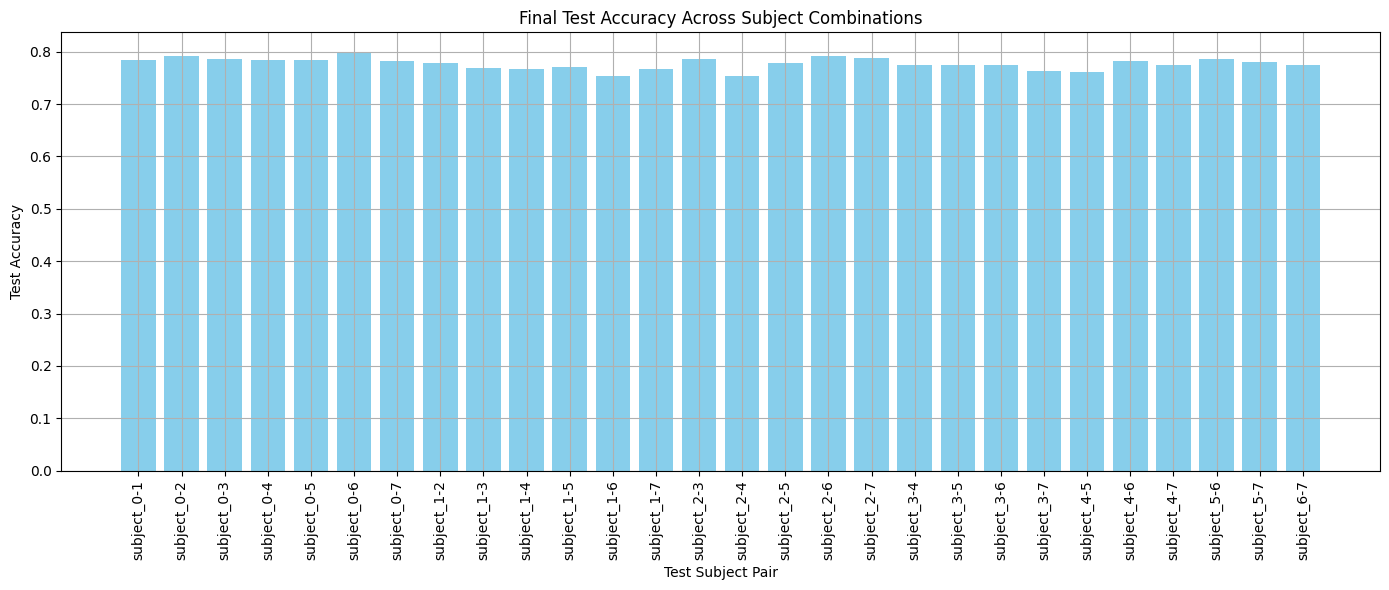

In [1]:
import os
import re
import matplotlib.pyplot as plt
import pandas as pd

def extract_final_test_accuracy_from_log(log_file_path):
    with open(log_file_path, 'r') as f:
        lines = f.readlines()

    last_accuracy = None
    for line in lines[::-1]:  # reverse search for speed
        match = re.search(r"Test Acc: ([0-9.]+)", line)
        if match:
            last_accuracy = float(match.group(1))
            break
    return last_accuracy

# Directory containing all 28 log files
logs_dir = r"D:\IDL_PROJECT_DATA\Final\logs"  # Update if needed

# Dictionary to store final accuracies
results = {}

# Process each log file
for filename in os.listdir(logs_dir):
    if filename.endswith("_metrics.log"):
        path = os.path.join(logs_dir, filename)
        subject_pair = filename.replace('_metrics.log', '')
        accuracy = extract_final_test_accuracy_from_log(path)
        if accuracy is not None:
            results[subject_pair] = accuracy

# Create a sorted DataFrame for plotting
df_results = pd.DataFrame(list(results.items()), columns=['Subject Pair', 'Final Test Accuracy'])
df_results = df_results.sort_values(by='Subject Pair')

# Plotting
plt.figure(figsize=(14, 6))
plt.bar(df_results['Subject Pair'], df_results['Final Test Accuracy'], color='skyblue')
plt.xticks(rotation=90)
plt.title("Final Test Accuracy Across Subject Combinations")
plt.ylabel("Test Accuracy")
plt.xlabel("Test Subject Pair")
plt.grid(True)
plt.tight_layout()
plt.show()


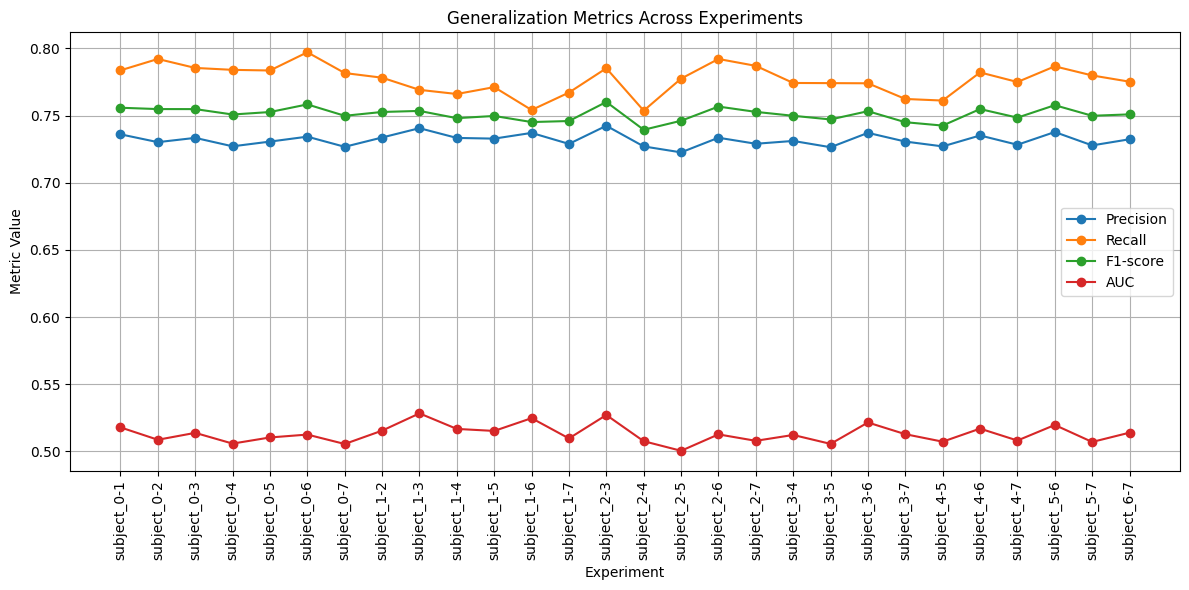

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV file
csv_path = r"D:\IDL_PROJECT_DATA\Final\generalization_metrics.csv"
df_metrics = pd.read_csv(csv_path)

# Plot generalization metrics
plt.figure(figsize=(12, 6))
for col in df_metrics.columns[1:]:
    plt.plot(df_metrics[df_metrics.columns[0]], df_metrics[col], marker='o', label=col)

plt.title("Generalization Metrics Across Experiments")
plt.xlabel(df_metrics.columns[0])
plt.ylabel("Metric Value")
plt.xticks(rotation=90)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
